In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

import wittgenstein as lw

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('bank.csv')

print("Өгөгдлийн хэмжээ:", df.shape)
df.head(10)

Өгөгдлийн хэмжээ: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [3]:
print("\nБүх баганын статистик мэдээлэл:")
display(df.describe(include='all'))


Бүх баганын статистик мэдээлэл:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [4]:
display(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
cols_drop = ['RowNumber', 'CustomerId', 'Surname']
cols_drop = [col for col in cols_drop if col in df.columns]
z = df.drop(columns=cols_drop)
print(cols_drop)
print("new data shape:", z.shape)
z.head()

['RowNumber', 'CustomerId', 'Surname']
new data shape: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
z2= z.copy()

if 'Gender' in z2.columns:
    z2['Gender'].replace(['Female', 'Male' ], [0, 1], inplace = True)

if 'Geography' in z2.columns:
    zeo_map = {
        'France':0,
        'Spain' :1, 
        'Germany':2
    }
    z2['Geography'] = z2['Geography'].map(zeo_map)
z2.head(10)
                    

C:\Users\Gateway\AppData\Local\Temp\ipykernel_14448\2493618159.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z2['Gender'].replace(['Female', 'Male' ], [0, 1], inplace = True)
C:\Users\Gateway\AppData\Local\Temp\ipykernel_14448\2493618159.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z2['

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0
5,645,1,1,44,8,113755.78,2,1,0,149756.71,1
6,822,0,1,50,7,0.00,2,1,1,10062.80,0
7,376,2,0,29,4,115046.74,4,1,0,119346.88,1
8,501,0,1,44,4,142051.07,2,0,1,74940.50,0
9,684,0,1,27,2,134603.88,1,1,1,71725.73,0


In [7]:
norm_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
norm_cols = [col for col in norm_cols if col in z2.columns]

scaler=MinMaxScaler()
z2[norm_cols] = scaler.fit_transform(z2[norm_cols])
print('Normalization columns:', norm_cols)
z2.head()

Normalization columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.538,0,0,0.324324,0.2,0.000000,1,1,1,0.506735,1
1,0.516,1,0,0.310811,0.1,0.334031,1,0,1,0.562709,0
2,0.304,0,0,0.324324,0.8,0.636357,3,1,0,0.569654,1
3,0.698,0,0,0.283784,0.1,0.000000,2,0,0,0.469120,0
4,1.000,1,0,0.337838,0.2,0.500246,1,1,1,0.395400,0


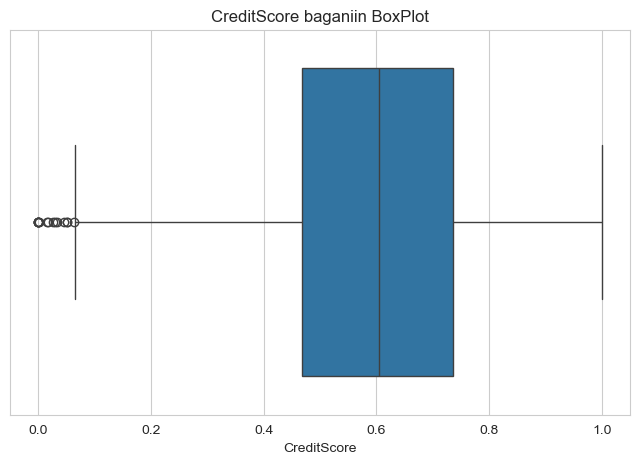

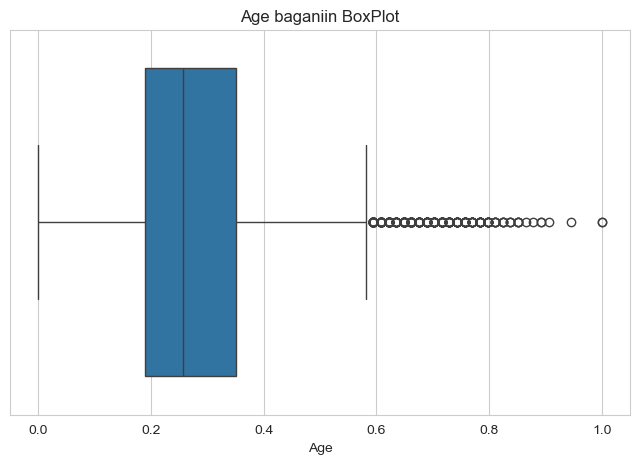

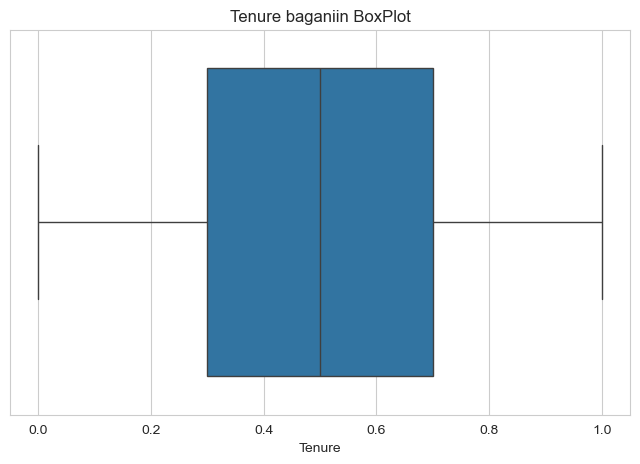

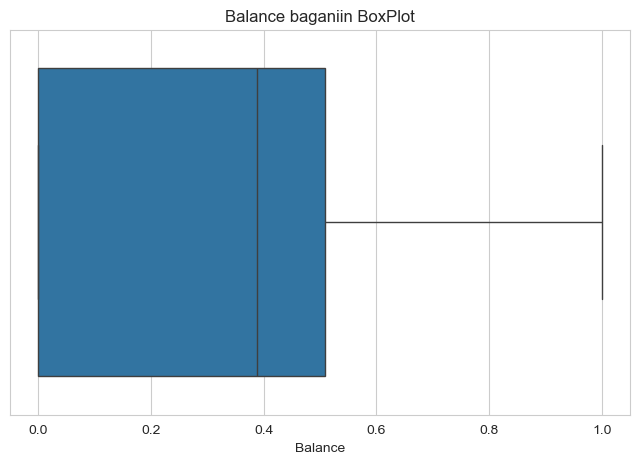

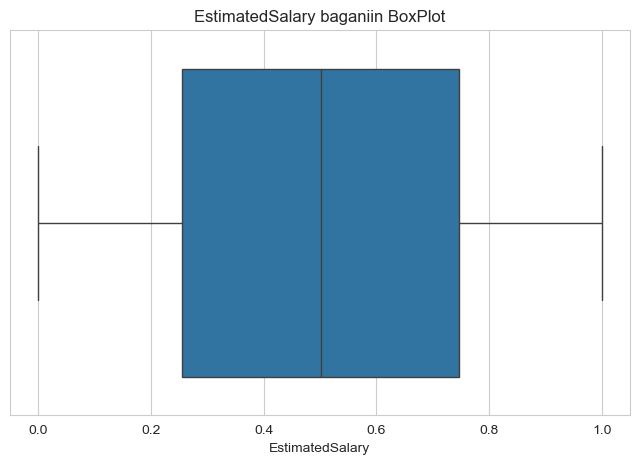

In [8]:
for col in norm_cols:
    plt.figure()
    sns.boxplot(x=z2[col])
    plt.title(f'{col} baganiin BoxPlot')
    plt.show()

In [12]:
def detect_outliers(data, columns):
    outlier_indices = set()

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75) 

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR  

        idx = data[(data[col] < lower) | (data[col] > upper)].index
        outlier_indices.update(idx)

    return list(outlier_indices)


outlier_idx = detect_outliers(z2, norm_cols) 
print('total outliers:', len(outlier_idx))

total outliers: 426


In [13]:
z3=z2.drop(index=outlier_idx).reset_index(drop=True)
print(len(z3))

9574


In [14]:
print(z3.shape)
z3.head()

(9574, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0.538,0,0,0.324324,0.2,0.000000,1,1,1,0.506735,1
1,0.516,1,0,0.310811,0.1,0.334031,1,0,1,0.562709,0
2,0.304,0,0,0.324324,0.8,0.636357,3,1,0,0.569654,1
3,0.698,0,0,0.283784,0.1,0.000000,2,0,0,0.469120,0
4,1.000,1,0,0.337838,0.2,0.500246,1,1,1,0.395400,0


In [15]:
X = z3.drop(['Exited'], axis = 1)
Y = z3['Exited']
print(Y.value_counts() )

Exited
0    7646
1    1928
Name: count, dtype: int64


In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size = 0.33, 
    random_state = 42, 
    stratify = Y
)
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)

X_train shape: (6414, 10)
X_test shape: (3160, 10)


In [17]:
train_df = X_train.copy()
train_df['Exited'] = Y_train

test_df = X_test.copy()
test_df['Exited'] = Y_test

ripper = lw.RIPPER(random_state = 42,  verbosity = 0)
ripper.fit(trainset = train_df, class_feat = 'Exited', pos_class = 1)


In [18]:
print(ripper.ruleset_.out_pretty())
cond_count = ripper.ruleset_.count_conds()
rule_count = len(ripper.ruleset_.rules)

print('niit durem:',rule_count)
print('niit nohtsol:', cond_count)

[[Age=>0.43 ^ IsActiveMember=0 ^ NumOfProducts=1 ^ HasCrCard=0 ^ Gender=1] V
[Age=>0.43 ^ IsActiveMember=0 ^ NumOfProducts=1 ^ Geography=2 ^ Balance=0.44-0.48] V
[Age=>0.43 ^ IsActiveMember=0 ^ NumOfProducts=1] V
[Age=0.35-0.43 ^ NumOfProducts=1 ^ Geography=2 ^ Balance=0.38-0.44 ^ CreditScore=0.34-0.43] V
[Age=0.35-0.43 ^ NumOfProducts=1 ^ IsActiveMember=0 ^ Geography=2 ^ Balance=0.53-0.59] V
[Age=0.35-0.43 ^ NumOfProducts=1 ^ IsActiveMember=0 ^ Balance=<0.28 ^ HasCrCard=0] V
[NumOfProducts=3] V
[Age=0.35-0.43 ^ NumOfProducts=1 ^ Gender=0 ^ Balance=<0.28 ^ IsActiveMember=0] V
[Geography=2 ^ NumOfProducts=1 ^ Age=0.35-0.43 ^ Tenure=0.1-0.2] V
[NumOfProducts=1 ^ Geography=2 ^ Age=0.35-0.43] V
[NumOfProducts=1 ^ Gender=0 ^ IsActiveMember=0 ^ Age=0.35-0.43 ^ CreditScore=0.71-0.77] V
[Age=>0.43 ^ IsActiveMember=0] V
[NumOfProducts=1 ^ Geography=2 ^ Balance=0.48-0.53 ^ Age=>0.43]]
None
niit durem: 13
niit nohtsol: 52


In [19]:
nb = GaussianNB()
nb.fit(X_train, Y_train)

,priors,None
,var_smoothing,1e-09


In [20]:
ripper_train_pred=ripper.predict(X_train)
ripper_test_pred=ripper.predict(X_test)

nb_train_pred = nb.predict(X_train)
nb_test_pred = nb.predict(X_test)

In [21]:
def evaluate_model(model_name, y_tr, pred_tr, y_te, pred_te):
    print(f"===== {model_name} =====")
    print("Train Accuracy   :", accuracy_score(y_tr, pred_tr))
    print("Test Accuracy    :", accuracy_score(y_te, pred_te))
    print("\nClassification Report (Test):")
    print(classification_report(y_te, pred_te))
    print()

evaluate_model("RIPPER", Y_train, ripper_train_pred, Y_test, ripper_test_pred)
evaluate_model("Naive Bayes", Y_train, nb_train_pred, Y_test, nb_test_pred)

===== RIPPER =====
Train Accuracy   : 0.8606173994387278
Test Accuracy    : 0.8430379746835444

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91      2524
           1       0.73      0.35      0.47       636

    accuracy                           0.84      3160
   macro avg       0.79      0.66      0.69      3160
weighted avg       0.83      0.84      0.82      3160


===== Naive Bayes =====
Train Accuracy   : 0.8401933270969754
Test Accuracy    : 0.8354430379746836

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      2524
           1       0.66      0.38      0.48       636

    accuracy                           0.84      3160
   macro avg       0.76      0.67      0.69      3160
weighted avg       0.82      0.84      0.82      3160




RIPPER Confusion Matrix:
[[2444   80]
 [ 416  220]]


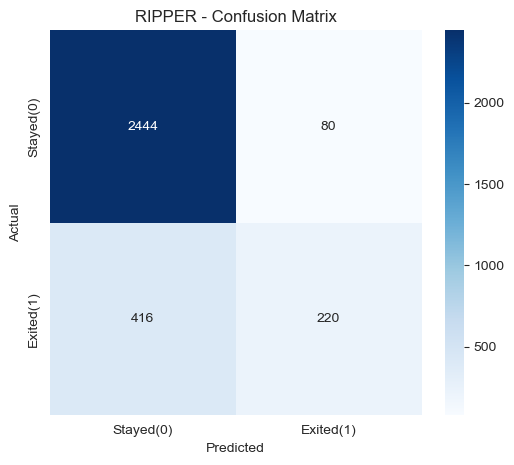

In [22]:
cm_ripper = confusion_matrix(Y_test, ripper_test_pred)
print("RIPPER Confusion Matrix:")
print(cm_ripper)

plt.figure(figsize=(6,5))
sns.heatmap(cm_ripper, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed(0)', 'Exited(1)'],
            yticklabels=['Stayed(0)', 'Exited(1)'])
plt.title("RIPPER - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Naive Bayes Confusion Matrix:
[[2398  126]
 [ 394  242]]


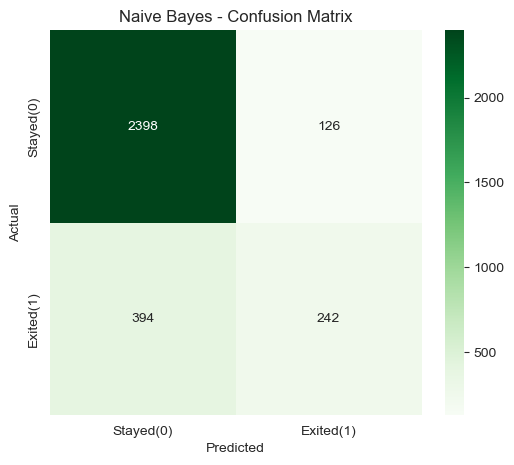

In [23]:
cm_nb = confusion_matrix(Y_test, nb_test_pred)
print("Naive Bayes Confusion Matrix:")
print(cm_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Stayed(0)', 'Exited(1)'],
            yticklabels=['Stayed(0)', 'Exited(1)'])
plt.title("Naive Bayes - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()